# Re-Organizing Behavioural Data

In [1]:
from scipy.io import loadmat
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt

## Load Data

In [2]:
# Behavioral Data
mouse = "cfm001mjr"
base_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/"
mat_file_path = base_path + mouse + "/PerceptualData_" + mouse +"_all.mat"
mat_data = loadmat(mat_file_path)

# Movie & Specs
filepath = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/cG_unmixed_dFF.h5"
with h5py.File(filepath, 'r') as mov_file:
    movie = mov_file["mov"][()]
    specs = mov_file["specs"]
    fps = specs["fps"][()][0][0]
    timeorigin = specs["timeorigin"][()][0][0]
    timebinning = specs["timebinning"][()][0][0]
    timestamps_table = specs["extra_specs"]["timestamps_table"][()].squeeze()
    timestamps_table_names = specs["extra_specs"]["timestamps_table_names"][()]
    timestamps_table_names = b''.join(timestamps_table_names.flatten()).decode("utf-8").split(';')

## Generating dataframe and CSV File for trial info

In [3]:
df = pd.DataFrame(mat_data["TrialInfo"])

def flatten_cell(cell):
    # Handle nested lists or arrays
    if isinstance(cell, (list, np.ndarray)):
        return cell[0] if len(cell) > 0 else None  # Extract the first element if not empty
    return cell

df = df.map(flatten_cell)
df = df.map(flatten_cell)

# Set the second row as the header (column names)
df.columns = df.iloc[0]  # Assign the second row as column names
df = df[1:]              # Remove the first row (now redundant)

# Reset the index to start from 0
df.reset_index(drop=True, inplace=True)

### Add column for trialID: Ensure 'Trial' is zero-padded to three digits and concatenate with 'Date'
df['TrialID'] = df['Date'].astype(str) + '_' + df['Recording#'].astype(str) + '_' + df['Trial'].astype(str).str.zfill(3)
cols = ['TrialID'] + [col for col in df.columns if col != 'TrialID']     # Reorder columns to place TrialID as the first column
df = df[cols]

### Add column for perceptual category
percept_cats = pd.DataFrame(mat_data["ConCrit"])

# Extract min and max contrast values from percept_cats
min_values = percept_cats.iloc[1:, 0].to_list()  # First column (min values)
max_values = percept_cats.iloc[1:, 1].to_list()  # Second column (max values)
bins = [min_values[0]] + max_values  # Combine min start and max values to define bin edges

# Use pd.cut to categorize contrasts
categories = pd.cut(
    df["Contrast"],
    bins=bins,  # Bin edges
    labels=[1, 2, 3],  # Assign category labels
    right=True,  # Include the right edge of bins
    include_lowest=True # Include 0 for category 1
)

# Add the new column to the DataFrame
df.insert(5, "PerceptualCat", categories)

### Add column for movie file name
df['MovieFile'] = "N:/GEVI_Wave/Analysis/Visual/" + mouse + '/20' + df['Date'].astype(str) + '/meas' + df['Recording#'].astype(str).str.zfill(2) + "/cG_unmixed_dFF.h5"

### Add column for BFM time
# Precompute delays for each unique (date, mouse) pair
def compute_delays(df):
    """
    Computes delays for each unique (Date, AnimalCode, Recording#) combination.

    Args:
    - df (pd.DataFrame): DataFrame containing 'Date', 'AnimalCode', and 'Recording#'.

    Returns:
    - dict: A dictionary with keys (Date, AnimalCode, Recording#) mapping to average delay.
    """
    delay_cache = {}
    basePath = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/"

    # Find unique (Date, AnimalCode, Recording#) combinations
    unique_pairs = df[["Date", "AnimalCode", "Recording#"]].drop_duplicates()

    for _, row in unique_pairs.iterrows():
        date = row["Date"]
        mouse = row["AnimalCode"]
        recording = row["Recording#"]
        path2 = f"{basePath}{mouse}/Volt_{date}_processed.mat"

        # Load the file
        data2 = loadmat(path2)
        df2 = pd.DataFrame(data2["MasterN"]).map(flatten_cell).map(flatten_cell).map(flatten_cell)

        # Ensure column names are correctly set
        df2.columns = df2.iloc[0]  
        df2 = df2[1:]  

        # Extract FrameAlignmentInfo for the correct recording
        delayEstimates = df2['FrameAlignmentInfo'][recording][0][0]

        # Compute mean delay for the recording
        delay_cache[(date, mouse, recording)] = np.mean(delayEstimates)

    return delay_cache

delay_cache = compute_delays(df)  # Precompute delays
df["Delay"] = df.apply(lambda row: delay_cache.get((row["Date"], row["AnimalCode"], row["Recording#"]), np.nan), axis=1)

df["BFMTime"] = df["Time"] + df["Delay"] +232/fps    # Compute BFM time
df.insert(3, "BFMTime", df.pop("BFMTime"))
#df.drop(columns=["Delay"], inplace=True)

# Rearrange columns and drop redundant ones
df.drop(columns=["Trial"], inplace=True)
df.insert(0, "AnimalCode", df.pop("AnimalCode"))
df.insert(1, "Date", df.pop("Date"))
df = df.rename(columns={"Recording#": "Recording"})

# Save to CSV
csv_path = "/Users/katiebrown/Library/CloudStorage/OneDrive-Stanford/Neuro_Project/Data/Behavioral_Data/cfm001mjr/TrialInfo.csv"
df.to_csv("Trial_Info.csv", index=False)

df

,AnimalCode,Date,TrialID,Time,BFMTime,Duration,Contrast,PerceptualCat,ReactTime,Rewarded?,Enticed?,Seen?,Consume?,Attrition?,Recording,EngagementScore,EngagementScore_S20,MovieFile,Delay
0,cfm001mjr,240506,240506_1_001,3.198,1.841983,0.529,0.06,3,11.88,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024050...,-2.832001
1,cfm001mjr,240506,240506_1_002,6.353,4.996983,0.522,0.023,1,8.725,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024050...,-2.832001
2,cfm001mjr,240506,240506_1_003,10.228,8.871983,0.532,0,1,4.85,0,0,0,0,1,1,0,0.057143,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024050...,-2.832001
3,cfm001mjr,240506,240506_1_004,14.599,13.242983,0.521,0.024,1,0.479,1,1,1,1,1,1,0.285714,0.086735,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024050...,-2.832001
4,cfm001mjr,240506,240506_1_005,43.217,41.860983,0.55,0.023,1,4.464,0,0,0,0,1,1,0,0.130952,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024050...,-2.832001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2498,cfm001mjr,240522,240522_1_439,933.166,934.220085,0.539,0.013,1,NaN,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024052...,-0.421899
2499,cfm001mjr,240522,240522_1_441,937.933,938.987085,0.54,0.02,1,NaN,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024052...,-0.421899
2500,cfm001mjr,240522,240522_1_442,939.876,940.930085,0.507,0.045,2,NaN,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024052...,-0.421899
2501,cfm001mjr,240522,240522_1_445,945.859,946.913085,0.509,0.013,1,NaN,0,0,0,0,1,1,0,0,N:/GEVI_Wave/Analysis/Visual/cfm001mjr/2024052...,-0.421899


## Checking Trial Info

### Time Alignment

In [4]:
## Generating ttl trace from df and movie

def generate_ttl_trace(df, fps, total_frames, date, recording):
    """
    Generates a TTL trace (1 for stimulus on, 0 for stimulus off) for each frame in the movie.

    Args:
    - df (pd.DataFrame): DataFrame containing 'BFMTime', 'Duration', and 'Date'.
    - fps (float): Frames per second of the movie.
    - total_frames (int): Total number of frames in the movie.
    - date (int or str): Date to filter trials (e.g., 240506).

    Returns:
    - np.ndarray: TTL trace with 1 (stimulus on) and 0 (stimulus off), one value per frame.
    """
    # Filter the dataframe to include only trials for the given date
    filtered_df = df[df["Date"] == int(date)]
    filtered_df = filtered_df[filtered_df["Recording"] == int(recording)]

    # Initialize the TTL trace with zeros (one entry per frame)
    ttl_trace = np.zeros(total_frames, dtype=int)

    # Loop through each trial in the filtered dataframe
    for _, trial in filtered_df.iterrows():
        # Compute the start and end frame indices for this trial
        start_frame = int(trial["BFMTime"] * fps)  # Convert BFMTime to frame index
        end_frame = int((trial["BFMTime"] + trial["Duration"]) * fps)  # Duration in frames

        # Ensure indices are within the bounds of the movie frames
        if start_frame < 0:
            continue  # Skip invalid trials
        if end_frame > total_frames:
            end_frame = total_frames  # Cap at the last frame

        # Set the frames for this trial to 1 (stimulus on)
        ttl_trace[start_frame:end_frame] = 1

    return ttl_trace


def get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin, timebinning=1):
    """
    Extracts the TTL trace from the movie specs.

    Args:
    - timestamps_table (np.ndarray): Timestamps table containing TTL data.
    - timestamps_table_names (np.ndarray): Column names for the timestamps table.
    - timeorigin (int): Starting index for the TTL signal.
    - timebinning (int, optional): Time binning factor for downsampling (default: 1).

    Returns:
    - np.ndarray: Extracted TTL signal.
    """
  
    # Get the column index for 'behavior_ttl'
    ttl_column = timestamps_table_names.index("behavior_ttl")

    # Extract the raw TTL signal starting from `timeorigin`
    ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]

    # Apply binning if `timebinning` is greater than 1
    if timebinning > 1:
        # Ensure the length of ttl_signal_raw is divisible by timebinning
        trimmed_length = len(ttl_signal_raw) - (len(ttl_signal_raw) % timebinning)
        ttl_signal_raw = ttl_signal_raw[:trimmed_length]
        
        # Reshape, average over bins, and round the result
        ttl_signal = np.round(np.mean(ttl_signal_raw.reshape(-1, timebinning), axis=1))
    else:
        ttl_signal = ttl_signal_raw

    return ttl_signal


/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_91595/1623666729.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ttl_signal_raw = timestamps_table[ttl_column, int(timeorigin):]
/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_91595/1623666729.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  start_frame = int(trial["BFMTime"] * fps)  # Convert BFMTime to frame index
/var/folders/0k/yytc9ywn0k3_j19jtm2h_cr00000gn/T/ipykernel_91595/1623666729.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array bef

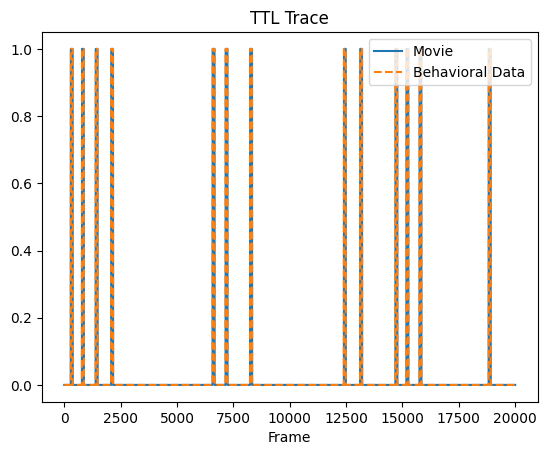

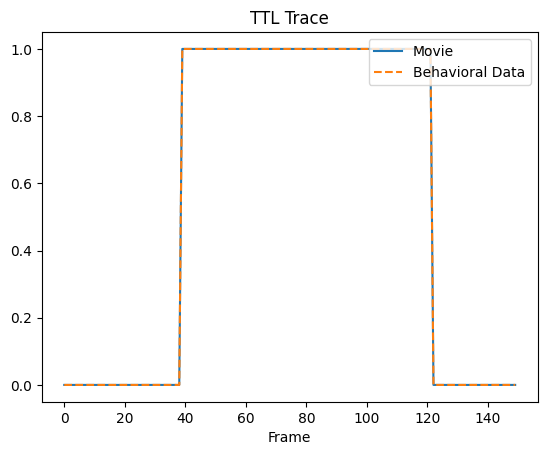

In [5]:
ttl_trace_movie = get_ttl_trace(timestamps_table, timestamps_table_names, timeorigin)
ttl_trace_df = generate_ttl_trace(df, fps, len(movie), 240506, 1)

plt.plot(ttl_trace_movie[0:20000])
plt.plot(ttl_trace_df[0:20000], ls='--')
plt.legend(["Movie", "Behavioral Data"], loc=1)
plt.xlabel("Frame")
plt.title("TTL Trace")
plt.show()
plt.plot(ttl_trace_movie[250:400])
plt.plot(ttl_trace_df[250:400], ls='--')
plt.legend(["Movie", "Behavioral Data"], loc=1)
plt.xlabel("Frame")
plt.title("TTL Trace");